In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)


In [13]:
df = pd.read_csv('ecommerce_bigdata.csv')
print(df.shape)
df.head()


(200, 7)


,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [3]:
df.info()
df.isnull().sum()
df.describe()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    200 non-null    object 
 1   Date             200 non-null    object 
 2   Region           200 non-null    object 
 3   ProductCategory  200 non-null    object 
 4   CustomerType     200 non-null    object 
 5   Sales            200 non-null    int64  
 6   Profit           200 non-null    float64
dtypes: float64(1), int64(1), object(5)
memory usage: 11.1+ KB


,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek      # 0 = Monday
df['DayOfYear'] = df['Date'].dt.dayofyear

# Cyclical encoding for month (helps linear models understand seasonality wrap-around)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Cyclical encoding for day of week
df['DOW_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DOW_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

df.head()


,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit,Year,Month,Day,DayOfWeek,DayOfYear,Month_sin,Month_cos,DOW_sin,DOW_cos
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44,2026,6,16,1,167,1.224647e-16,-1.000000e+00,0.781831,0.623490
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32,2026,2,12,3,43,8.660254e-01,5.000000e-01,0.433884,-0.900969
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10,2026,3,1,6,60,1.000000e+00,6.123234e-17,-0.781831,0.623490
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57,2026,6,3,2,154,1.224647e-16,-1.000000e+00,0.974928,-0.222521
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48,2026,1,21,2,21,5.000000e-01,8.660254e-01,0.974928,-0.222521


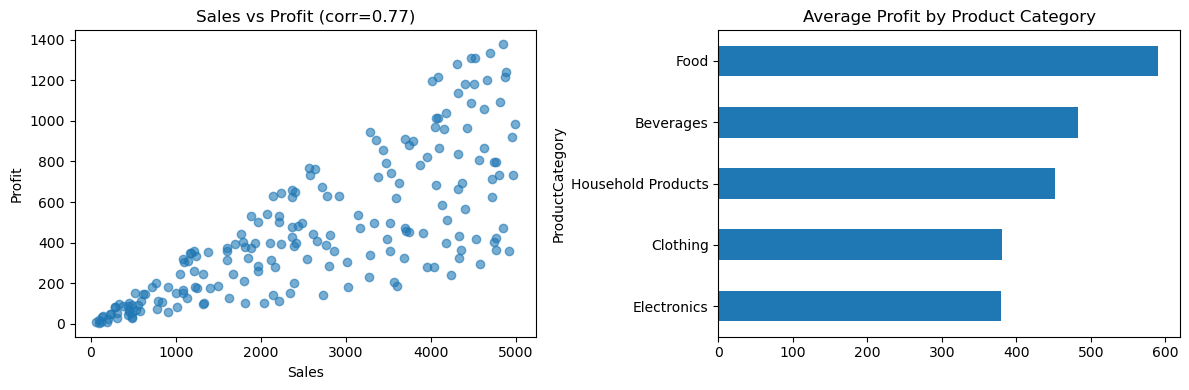

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(df['Sales'], df['Profit'], alpha=0.6)
ax[0].set_xlabel('Sales')
ax[0].set_ylabel('Profit')
ax[0].set_title(f"Sales vs Profit (corr={df['Sales'].corr(df['Profit']):.2f})")

df.groupby('ProductCategory')['Profit'].mean().sort_values().plot(kind='barh', ax=ax[1])
ax[1].set_title('Average Profit by Product Category')

plt.tight_layout()
plt.show()


In [6]:
numeric_features = ['Sales', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear',
                     'Month_sin', 'Month_cos', 'DOW_sin', 'DOW_cos']
categorical_features = ['Region', 'ProductCategory', 'CustomerType']

X = df[numeric_features + categorical_features]
y = df['Profit']

X.head()


,Sales,Year,Month,Day,DayOfWeek,DayOfYear,Month_sin,Month_cos,DOW_sin,DOW_cos,Region,ProductCategory,CustomerType
0,4924,2026,6,16,1,167,1.224647e-16,-1.000000e+00,0.781831,0.623490,Eastern,Electronics,Wholesale
1,3283,2026,2,12,3,43,8.660254e-01,5.000000e-01,0.433884,-0.900969,Central,Electronics,Retail
2,4049,2026,3,1,6,60,1.000000e+00,6.123234e-17,-0.781831,0.623490,Northern,Food,Online
3,4331,2026,6,3,2,154,1.224647e-16,-1.000000e+00,0.974928,-0.222521,Western,Household Products,Online
4,3283,2026,1,21,2,21,5.000000e-01,8.660254e-01,0.974928,-0.222521,Western,Household Products,Retail


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")


Train size: 160 rows
Test size:  40 rows


In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


In [9]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)


In [10]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=4, random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)


In [ ]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.3f}\n")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate(y_test, y_pred_lr, 'Linear Regression'))
results.append(evaluate(y_test, y_pred_dt, 'Decision Tree'))

results_df = pd.DataFrame(results).set_index('Model')
results_df


--- Linear Regression ---
MAE:  148.90
RMSE: 191.19
R2:   0.676

--- Decision Tree ---
MAE:  179.71
RMSE: 257.63
R2:   0.412



,MAE,RMSE,R2
Model,,,
Linear Regression,148.900094,191.185735,0.676456
Decision Tree,179.713671,257.631105,0.412485


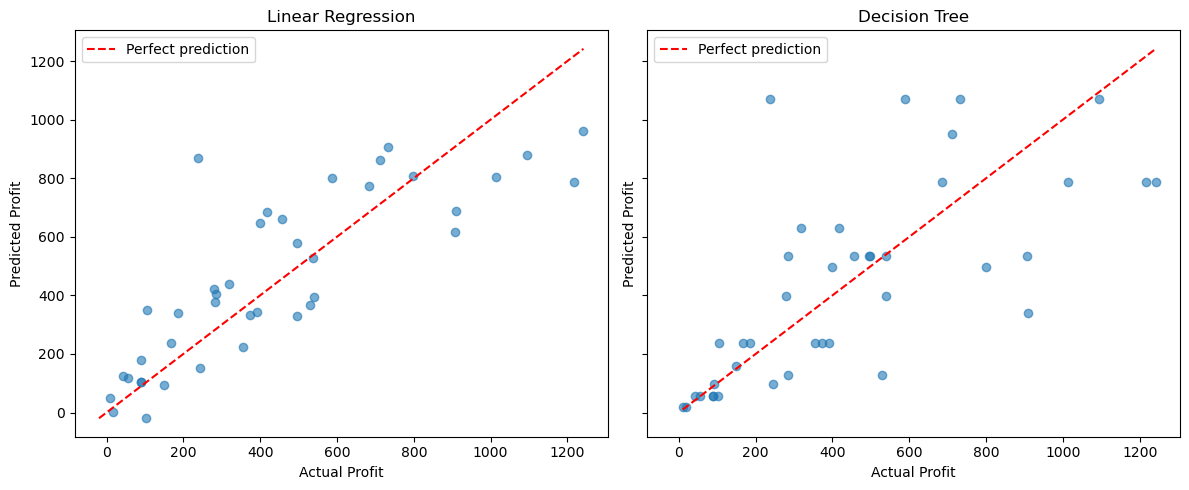

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for a, y_pred, name in zip(ax, [y_pred_lr, y_pred_dt], ['Linear Regression', 'Decision Tree']):
    a.scatter(y_test, y_pred, alpha=0.6)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    a.plot(lims, lims, 'r--', label='Perfect prediction')
    a.set_xlabel('Actual Profit')
    a.set_ylabel('Predicted Profit')
    a.set_title(name)
    a.legend()

plt.tight_layout()
plt.show()
